# Diabetes Prediction: From Raw Data to Evaluation

**Task:** Binary Classification. Predict whether a patient has diabetes (`1`) or not (`0`).

**Roadmap:**
```
0. Setup and load the data
1. Understand the data (feature table)
2. EDA: one column, then two columns
3. Imputation (missing values)
4. Cleaning (duplicates, inconsistent text)
5. Encoding (text to numbers)
6. Correlation Matrix
7. Train/Test Split and Standardization
8. Models: XGBoost and LightGBM
9. Exercise: compute the metrics yourself
10. Answers: Confusion Matrix and all metrics
11. SHAP: why did the model decide this?
```

## Student / Project Information

**Full Name:** Awadh Mohammed Alhajri  
**Project:** Diabetes Prediction: From Raw Data to Evaluation  
**Training Programme:** [CONFIRM EXACT PROGRAMME NAME BEFORE PUBLISHING]  
**Academy:** [SDAIA Academy](https://github.com/SDAIAAcademy)  
**Tag:** #SDAIAAcademy


## 0. Setup

In [1]:
# !pip install xgboost lightgbm shap -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

# Bigger, cleaner plots for the classroom
sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = {0: "#4C72B0", 1: "#DD8452"}       # blue = No diabetes, orange = Diabetes
LABELS = {0: "No diabetes", 1: "Diabetes"}

In [2]:
# @title Create the dataset (run this cell, think of it as the export from the hospital system)
rng = np.random.default_rng(7)
n = 1500

age = rng.integers(20, 80, n)
bmi = rng.normal(28, 6, n).clip(16, 50)
glucose = 85 + 0.8 * (bmi - 28) + 0.3 * (age - 45) + rng.normal(15, 22, n)
glucose = np.where(glucose < 65, rng.uniform(65, 80, n), glucose).clip(max=220)
bp = 75 + 0.4 * (bmi - 28) + rng.normal(0, 9, n)
activity = rng.choice(["Low", "Medium", "High"], n, p=[0.4, 0.35, 0.25])
smoking = rng.choice(["Never", "Former", "Current"], n, p=[0.55, 0.25, 0.20])
family = rng.choice(["Yes", "No"], n, p=[0.3, 0.7])
gender = rng.choice(["Male", "Female"], n)

logit = (-1.2 + 0.05 * (glucose - 105) + 1.3 * (glucose >= 126) + 0.07 * (bmi - 28)
         + 0.03 * (age - 45) + 1.0 * (family == "Yes") + 0.015 * (bp - 75)
         + 0.6 * (smoking == "Current") + 0.25 * (smoking == "Former")
         - 0.6 * (activity == "Medium") - 1.3 * (activity == "High"))
diabetes = rng.binomial(1, 1 / (1 + np.exp(-logit)))

# how the hospital system actually records things
gender = np.where(rng.random(n) < 0.12, rng.choice(["male", "M", "female", "F", "Female "], n), gender)
glucose = np.where(rng.random(n) < 0.02, 0, glucose.round())
bp = np.where(rng.random(n) < 0.03, 0, bp.round())
insulin = np.where(rng.random(n) < 0.09, np.nan, (100 + 3 * (bmi - 28) + rng.normal(0, 35, n)).clip(15, 350).round())
bmi = np.where(rng.random(n) < 0.03, np.nan, bmi.round(1))
smoking = np.where(rng.random(n) < 0.04, None, smoking)

raw = pd.DataFrame({"PatientID": np.arange(1001, 1001 + n), "Age": age, "Gender": gender, "BMI": bmi,
                    "Glucose": glucose, "BloodPressure": bp, "Insulin": insulin, "FamilyHistory": family,
                    "SmokingStatus": smoking, "ActivityLevel": activity, "Diabetes": diabetes})
raw = pd.concat([raw, raw.sample(45, random_state=3)]).sample(frac=1, random_state=4)
raw.to_csv("diabetes_raw.csv", index=False)
print("Saved diabetes_raw.csv")

Saved diabetes_raw.csv


In [3]:
df = pd.read_csv("diabetes_raw.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head(10)

Rows: 1545
Columns: 11


,PatientID,Age,Gender,BMI,Glucose,BloodPressure,Insulin,FamilyHistory,SmokingStatus,ActivityLevel,Diabetes
0,1189,48,Male,28.4,86.0,61.0,94.0,No,Never,Low,0
1,2342,50,Male,19.9,106.0,69.0,99.0,Yes,Current,Medium,1
2,1727,69,Female,28.6,153.0,60.0,121.0,No,Never,Medium,1
3,1794,65,Female,27.5,105.0,66.0,137.0,No,Current,High,0
4,1550,42,Female,36.4,123.0,95.0,165.0,No,Never,High,0
5,1032,53,Male,29.6,118.0,76.0,127.0,No,Former,Low,0
6,2012,47,Female,23.8,107.0,65.0,48.0,No,Former,Low,1
7,1439,69,Male,26.5,99.0,71.0,106.0,Yes,NaN,Medium,1
8,2320,24,Male,36.7,79.0,85.0,NaN,Yes,NaN,Low,1
9,2324,36,Female,26.5,68.0,55.0,108.0,No,Current,Low,0


## 1. Understand the Data

| Feature | Type | Explanation (English) | الشرح |
|---|---|---|---|
| `PatientID` | ID | Unique number for each patient. Not used for prediction | رقم تعريف المريض، لا يستخدم في التنبؤ |
| `Age` | Numerical | Age in years. Risk increases with age | العمر بالسنوات، والخطر يزيد مع التقدم في العمر |
| `Gender` | Categorical (binary) | Male or Female | الجنس: ذكر او انثى |
| `BMI` | Numerical | Body Mass Index (kg/m²). Obesity reduces insulin sensitivity | مؤشر كتلة الجسم، والسمنة تقلل استجابة الجسم للانسولين |
| `Glucose` | Numerical | Fasting blood sugar (mg/dL). 126 or above is the diagnostic threshold | سكر الدم الصائم، و 126 فاكثر هو حد التشخيص |
| `BloodPressure` | Numerical | Diastolic blood pressure (mmHg) | ضغط الدم الانبساطي |
| `Insulin` | Numerical | Insulin level (µU/mL). High values suggest insulin resistance | مستوى الانسولين، وارتفاعه يدل على مقاومة الانسولين |
| `FamilyHistory` | Categorical (binary) | Yes if a parent or sibling has diabetes | نعم اذا كان احد الوالدين او الاخوة مصابا بالسكري |
| `SmokingStatus` | Categorical (nominal) | Never, Former, or Current smoker | حالة التدخين: لم يدخن، مدخن سابق، مدخن حالي |
| `ActivityLevel` | Categorical (ordinal) | Low, Medium, or High physical activity | مستوى النشاط البدني: منخفض، متوسط، مرتفع |
| `Diabetes` | **Target** | 1 = has diabetes, 0 = does not | المتغير المستهدف: 1 مصاب، 0 غير مصاب |

## 2. EDA (Exploratory Data Analysis)

**Goal:** understand the data and find its problems **before** we touch it.

We look at it in two ways:
- **Univariate:** one column at a time. What does it look like?
- **Bivariate:** two columns together. Is there a relationship?

### 2.1 General overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1545 entries, 0 to 1544
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      1545 non-null   int64  
 1   Age            1545 non-null   int64  
 2   Gender         1545 non-null   object 
 3   BMI            1499 non-null   float64
 4   Glucose        1545 non-null   float64
 5   BloodPressure  1545 non-null   float64
 6   Insulin        1406 non-null   float64
 7   FamilyHistory  1545 non-null   object 
 8   SmokingStatus  1491 non-null   object 
 9   ActivityLevel  1545 non-null   object 
 10  Diabetes       1545 non-null   int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 132.9+ KB


In [5]:
df.describe().round(1)

,PatientID,Age,BMI,Glucose,BloodPressure,Insulin,Diabetes
count,1545.0,1545.0,1499.0,1545.0,1545.0,1406.0,1545.0
mean,1748.5,49.8,28.0,100.8,72.7,101.0,0.3
std,433.1,17.3,6.0,24.9,15.4,39.1,0.5
min,1001.0,20.0,16.0,0.0,0.0,15.0,0.0
25%,1373.0,35.0,23.7,85.0,68.0,75.0,0.0
50%,1747.0,50.0,27.7,101.0,75.0,101.0,0.0
75%,2124.0,65.0,32.1,116.0,81.0,127.0,1.0
max,2500.0,79.0,45.9,183.0,107.0,219.0,1.0


**What to notice:**
- `Glucose` and `BloodPressure` have a **minimum of 0**. A living person cannot have zero blood sugar or zero blood pressure, so these are **hidden missing values**
- `BMI`, `Insulin`, and `SmokingStatus` have fewer non-null values than the number of rows, so they have **missing values**

In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicated rows:", df.duplicated().sum())

Missing values per column:
PatientID          0
Age                0
Gender             0
BMI               46
Glucose            0
BloodPressure      0
Insulin          139
FamilyHistory      0
SmokingStatus     54
ActivityLevel      0
Diabetes           0
dtype: int64

Duplicated rows: 45


### 2.2 Univariate: the Target (`Diabetes`)

**Question:** how many patients have diabetes? Are the classes balanced?

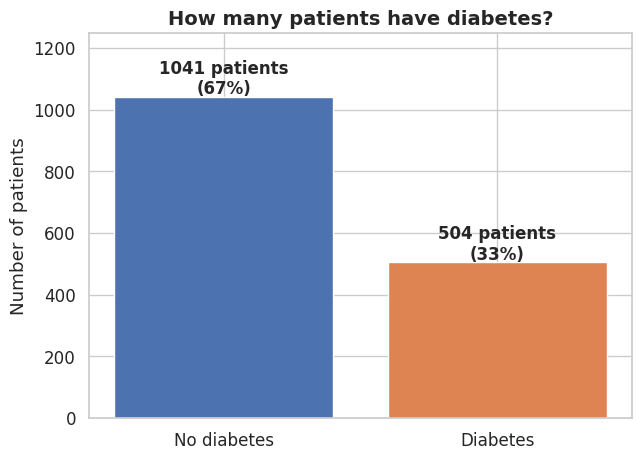

In [7]:
counts = df["Diabetes"].value_counts().sort_index()
percent = counts / counts.sum() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar([LABELS[0], LABELS[1]], counts, color=[COLORS[0], COLORS[1]])

for bar, c, p in zip(bars, counts, percent):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             f"{c} patients\n({p:.0f}%)", ha="center", fontsize=12, fontweight="bold")

plt.title("How many patients have diabetes?", fontsize=14, fontweight="bold")
plt.ylabel("Number of patients")
plt.ylim(0, counts.max() * 1.2)
plt.show()

**How to read it:** about 2 out of 3 patients do not have diabetes. The classes are **imbalanced**. A model that always says "No diabetes" would already get about 67% Accuracy without learning anything, so Accuracy alone can fool us.

### 2.3 Univariate: a numerical column (`Glucose`)

**Question:** what is the typical glucose level? Is there anything strange?

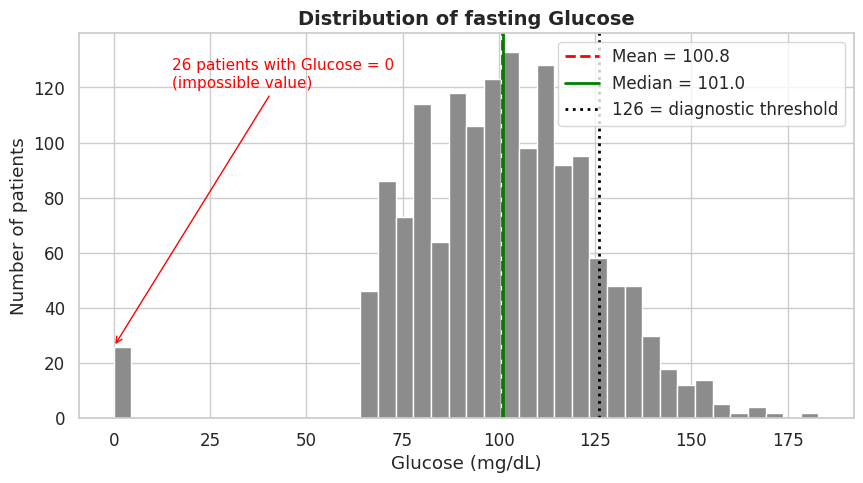

In [8]:
glucose = df["Glucose"]

plt.figure(figsize=(10, 5))
plt.hist(glucose, bins=40, color="#8C8C8C", edgecolor="white")

plt.axvline(glucose.mean(), color="red", linestyle="--", linewidth=2,
            label=f"Mean = {glucose.mean():.1f}")
plt.axvline(glucose.median(), color="green", linestyle="-", linewidth=2,
            label=f"Median = {glucose.median():.1f}")
plt.axvline(126, color="black", linestyle=":", linewidth=2,
            label="126 = diagnostic threshold")

zeros = (glucose == 0).sum()
plt.annotate(f"{zeros} patients with Glucose = 0\n(impossible value)",
             xy=(0, zeros), xytext=(15, 120),
             arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=11)

plt.title("Distribution of fasting Glucose", fontsize=14, fontweight="bold")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Number of patients")
plt.legend()
plt.show()

**How to read it:**
- Most patients are between about 80 and 130 mg/dL
- The bar at **0** is not real: these are missing values recorded as 0
- The zeros pull the mean slightly below the median. With more wrong or extreme values the gap grows, while the median stays stable. The median is more **robust**, which is why we use it later to fill missing numbers

### 2.4 Univariate: a categorical column (`Gender`)

**Question:** what values does this column contain?

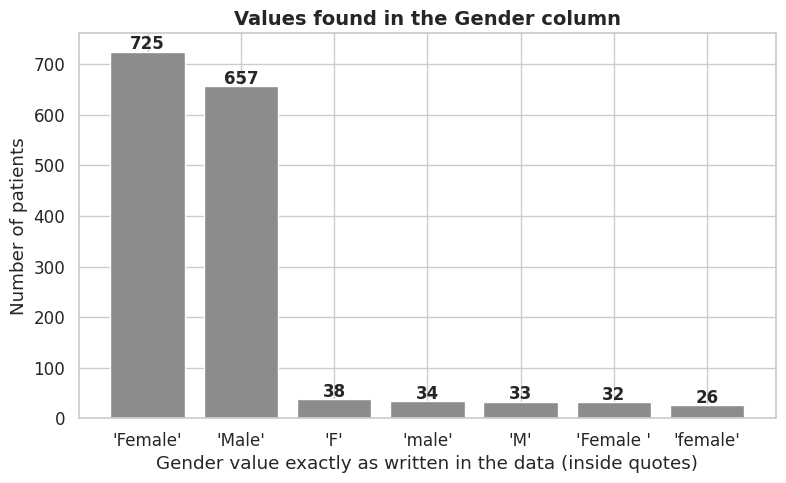

In [9]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar([f"'{v}'" for v in gender_counts.index], gender_counts.values, color="#8C8C8C")

for bar, c in zip(bars, gender_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(c),
             ha="center", fontsize=12, fontweight="bold")

plt.title("Values found in the Gender column", fontsize=14, fontweight="bold")
plt.xlabel("Gender value exactly as written in the data (inside quotes)")
plt.ylabel("Number of patients")
plt.show()

**How to read it:** there should be **2** categories, but we find several. `Male`, `male`, and `M` mean the same thing. `"Female "` has an extra space at the end. The computer treats each spelling as a different category, so we must clean it.

### 2.5 Bivariate: numerical vs target (`Glucose` vs `Diabetes`)

**Question:** do diabetic patients have higher glucose?

We ignore the zeros in this plot because we already know they are wrong.

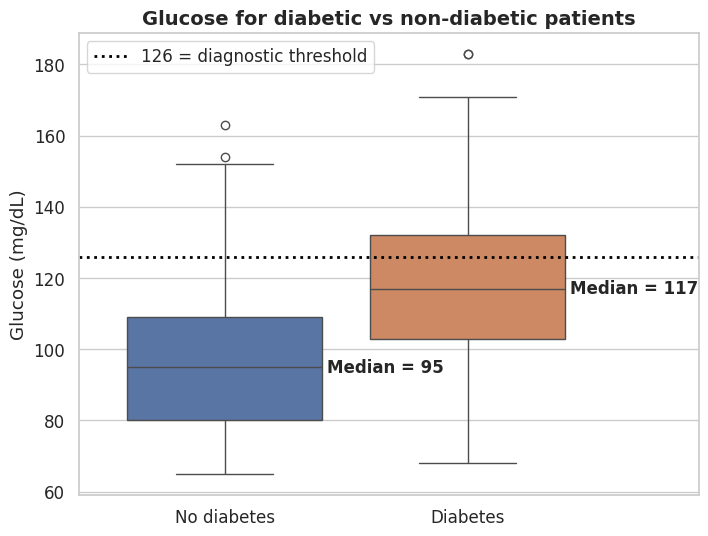

In [10]:
valid = df[df["Glucose"] > 0]

plt.figure(figsize=(8, 6))
sns.boxplot(data=valid, x="Diabetes", y="Glucose", hue="Diabetes", palette=COLORS, legend=False)

for group in [0, 1]:
    median = valid.loc[valid["Diabetes"] == group, "Glucose"].median()
    plt.text(group + 0.42, median, f"Median = {median:.0f}",
             ha="left", va="center", fontsize=12, fontweight="bold")

plt.axhline(126, color="black", linestyle=":", linewidth=2, label="126 = diagnostic threshold")
plt.xticks([0, 1], [LABELS[0], LABELS[1]])
plt.xlim(-0.6, 1.95)
plt.title("Glucose for diabetic vs non-diabetic patients", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Glucose (mg/dL)")
plt.legend(loc="upper left")
plt.show()

**How to read it:**
- The box holds the middle 50% of patients, and the line inside the box is the median
- The diabetic box is clearly higher, so `Glucose` separates the two groups well. It should be a strong feature for the model
- The boxes still overlap, so `Glucose` alone is not enough, and we need the other features too

### 2.6 Bivariate: categorical vs target (`ActivityLevel` vs `Diabetes`)

**Question:** does physical activity change the diabetes rate?

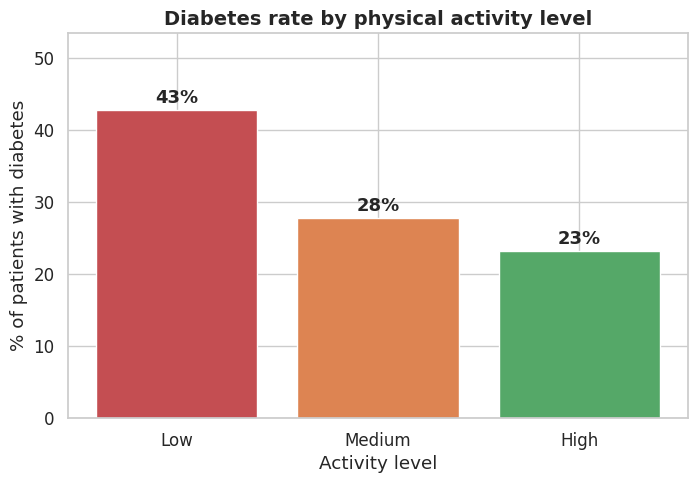

In [11]:
rate = df.groupby("ActivityLevel")["Diabetes"].mean() * 100
rate = rate.reindex(["Low", "Medium", "High"])

plt.figure(figsize=(8, 5))
bars = plt.bar(rate.index, rate.values, color=["#C44E52", "#DD8452", "#55A868"])

for bar, r in zip(bars, rate.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{r:.0f}%",
             ha="center", fontsize=13, fontweight="bold")

plt.title("Diabetes rate by physical activity level", fontsize=14, fontweight="bold")
plt.xlabel("Activity level")
plt.ylabel("% of patients with diabetes")
plt.ylim(0, rate.max() * 1.25)
plt.show()

**How to read it:** the diabetes rate drops as activity goes up. The order `Low < Medium < High` has meaning, which matters later when we choose the encoder.

### 2.7 Bivariate: numerical vs numerical (`Age` vs `Glucose`)

**Question:** does glucose rise with age? Where do the diabetic patients sit?

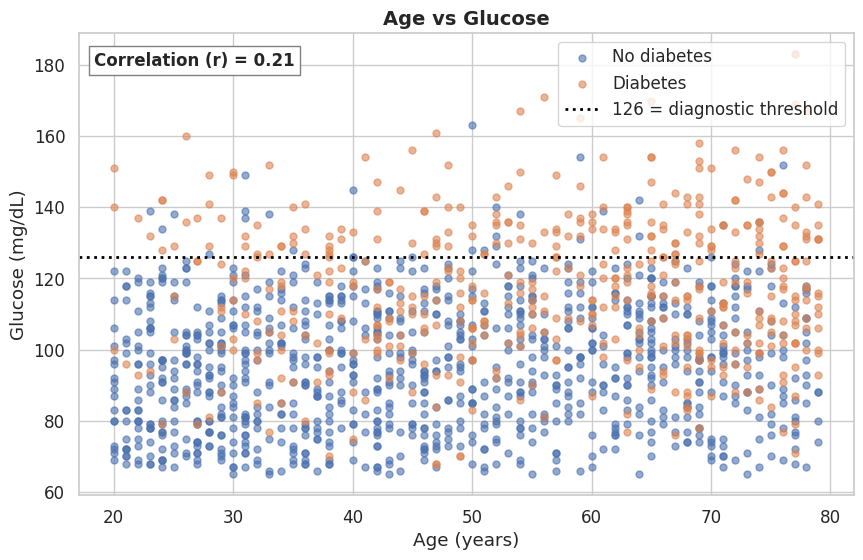

In [12]:
valid = df[df["Glucose"] > 0]

plt.figure(figsize=(10, 6))
for group in [0, 1]:
    part = valid[valid["Diabetes"] == group]
    plt.scatter(part["Age"], part["Glucose"], color=COLORS[group], label=LABELS[group],
                alpha=0.6, s=25)

plt.axhline(126, color="black", linestyle=":", linewidth=2, label="126 = diagnostic threshold")

r = valid["Age"].corr(valid["Glucose"])
plt.text(0.02, 0.96, f"Correlation (r) = {r:.2f}", transform=plt.gca().transAxes,
         va="top", fontsize=12, fontweight="bold", bbox=dict(facecolor="white", edgecolor="gray"))

plt.title("Age vs Glucose", fontsize=14, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Glucose (mg/dL)")
plt.legend(loc="upper right")
plt.show()

**How to read it:**
- Each dot is one patient
- The cloud rises slightly from left to right: older patients tend to have a bit higher glucose (weak positive correlation)
- Orange dots (diabetes) gather at the top, above the 126 line

### EDA summary: the problems we found

| Problem | Column(s) | Fix in |
|---|---|---|
| Missing values (NaN) | `BMI`, `Insulin`, `SmokingStatus` | Imputation |
| Hidden missing values (0) | `Glucose`, `BloodPressure` | Imputation |
| Duplicated rows | whole row | Cleaning |
| Inconsistent text | `Gender` | Cleaning |
| Text columns | `Gender`, `FamilyHistory`, `SmokingStatus`, `ActivityLevel` | Encoding |

## 3. Imputation (Missing Values)

**Step 1:** turn the hidden missing values (0) into real missing values (NaN), so we can see them.

In [13]:
df["Glucose"] = df["Glucose"].replace(0, np.nan)
df["BloodPressure"] = df["BloodPressure"].replace(0, np.nan)

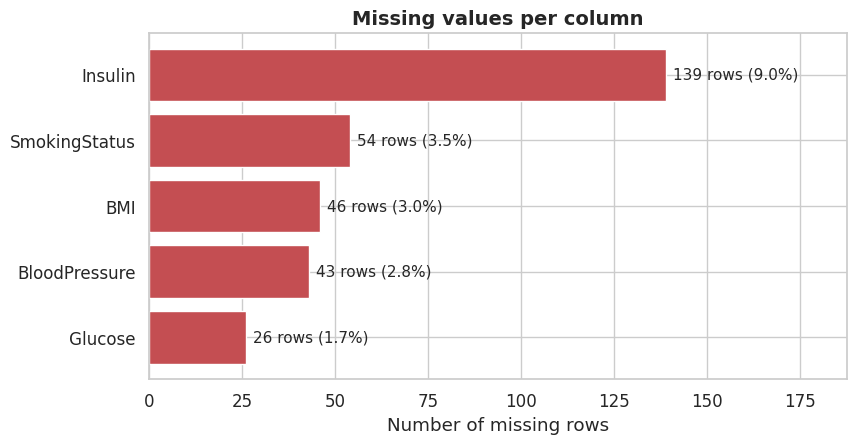

In [14]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values()
missing_percent = missing / len(df) * 100

plt.figure(figsize=(9, 4.5))
bars = plt.barh(missing.index, missing.values, color="#C44E52")

for bar, m, p in zip(bars, missing.values, missing_percent.values):
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
             f"{m} rows ({p:.1f}%)", va="center", fontsize=11)

plt.title("Missing values per column", fontsize=14, fontweight="bold")
plt.xlabel("Number of missing rows")
plt.xlim(0, missing.max() * 1.35)
plt.show()

**Step 2:** choose how to fill each type of column.

| Column type | Method | Why |
|---|---|---|
| Numerical | **Median** | Not affected by extreme or wrong values, unlike the mean |
| Categorical | **Mode** (most frequent value) | We cannot compute an average of text |

> **Note:** to keep this lesson simple, we fill before the split. In a real project, compute the median and mode **from the training set only**, then apply them to the test set. Otherwise information from the test set leaks into training (Data Leakage).

In [15]:
numerical_cols = ["BMI", "Glucose", "BloodPressure", "Insulin"]

for col in numerical_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"{col}: filled with median = {median_value}")

mode_value = df["SmokingStatus"].mode()[0]
df["SmokingStatus"] = df["SmokingStatus"].fillna(mode_value)
print(f"SmokingStatus: filled with mode = {mode_value}")

BMI: filled with median = 27.7
Glucose: filled with median = 102.0
BloodPressure: filled with median = 75.0
Insulin: filled with median = 101.0
SmokingStatus: filled with mode = Never


In [16]:
print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


## 4. Cleaning

### 4.1 Duplicated rows

The same patient recorded twice. If one copy goes to training and the other to testing, the model is tested on a patient it has already seen, so the score looks better than it really is.

In [17]:
print("Rows before:", len(df))
print("Duplicated rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Rows after:", len(df))

Rows before: 1545
Duplicated rows: 45
Rows after: 1500


### 4.2 Inconsistent text in `Gender`

Two steps: remove extra spaces and unify the letter case, then map every spelling to one standard value.

In [18]:
print("Before:", list(df["Gender"].unique()))

df["Gender"] = df["Gender"].str.strip().str.lower()

df["Gender"] = df["Gender"].replace({
    "m": "male",
    "f": "female",
})

print("After: ", list(df["Gender"].unique()))

Before: ['Male', 'Female', 'female', 'Female ', 'male', 'M', 'F']
After:  ['male', 'female']


### 4.3 Drop columns that do not help prediction

`PatientID` is just a number given to each patient. It has no medical meaning.

In [19]:
df = df.drop(columns=["PatientID"])

## 5. Encoding

Models only understand numbers. The right encoder depends on the **type** of the categorical column:

| Column | Type | Encoder | Result |
|---|---|---|---|
| `Gender` | Binary (2 values) | **Binary / Label mapping** | female = 0, male = 1 |
| `FamilyHistory` | Binary (2 values) | **Binary / Label mapping** | No = 0, Yes = 1 |
| `ActivityLevel` | **Ordinal** (has an order) | **Ordinal Encoding** | Low = 0, Medium = 1, High = 2 |
| `SmokingStatus` | **Nominal** (no order) | **One-Hot Encoding** | one 0/1 column per category |

**Why not Ordinal Encoding for `SmokingStatus`?** If we write Never = 0, Former = 1, Current = 2, the model thinks Current is "twice" Former. There is no such order, so we give each category its own column instead.

In [20]:
df["Gender"] = df["Gender"].map({"female": 0, "male": 1})

df["FamilyHistory"] = df["FamilyHistory"].map({"No": 0, "Yes": 1})

df["ActivityLevel"] = df["ActivityLevel"].map({"Low": 0, "Medium": 1, "High": 2})

df = pd.get_dummies(df, columns=["SmokingStatus"], prefix="Smoking", dtype=int)

df.head()

,Age,Gender,BMI,Glucose,BloodPressure,Insulin,FamilyHistory,ActivityLevel,Diabetes,Smoking_Current,Smoking_Former,Smoking_Never
0,48,1,28.4,86.0,61.0,94.0,0,0,0,0,0,1
1,50,1,19.9,106.0,69.0,99.0,1,1,1,1,0,0
2,69,0,28.6,153.0,60.0,121.0,0,1,1,0,0,1
3,65,0,27.5,105.0,66.0,137.0,0,2,0,1,0,0
4,42,0,36.4,123.0,95.0,165.0,0,2,0,0,0,1


## 6. Correlation Matrix

Now every column is a number, so we can measure the relationship between each pair.

**How to read the numbers:**
- **+1**: both go up together
- **0**: no linear relationship
- **-1**: when one goes up, the other goes down

We show only the lower half, because the upper half is a mirror copy.

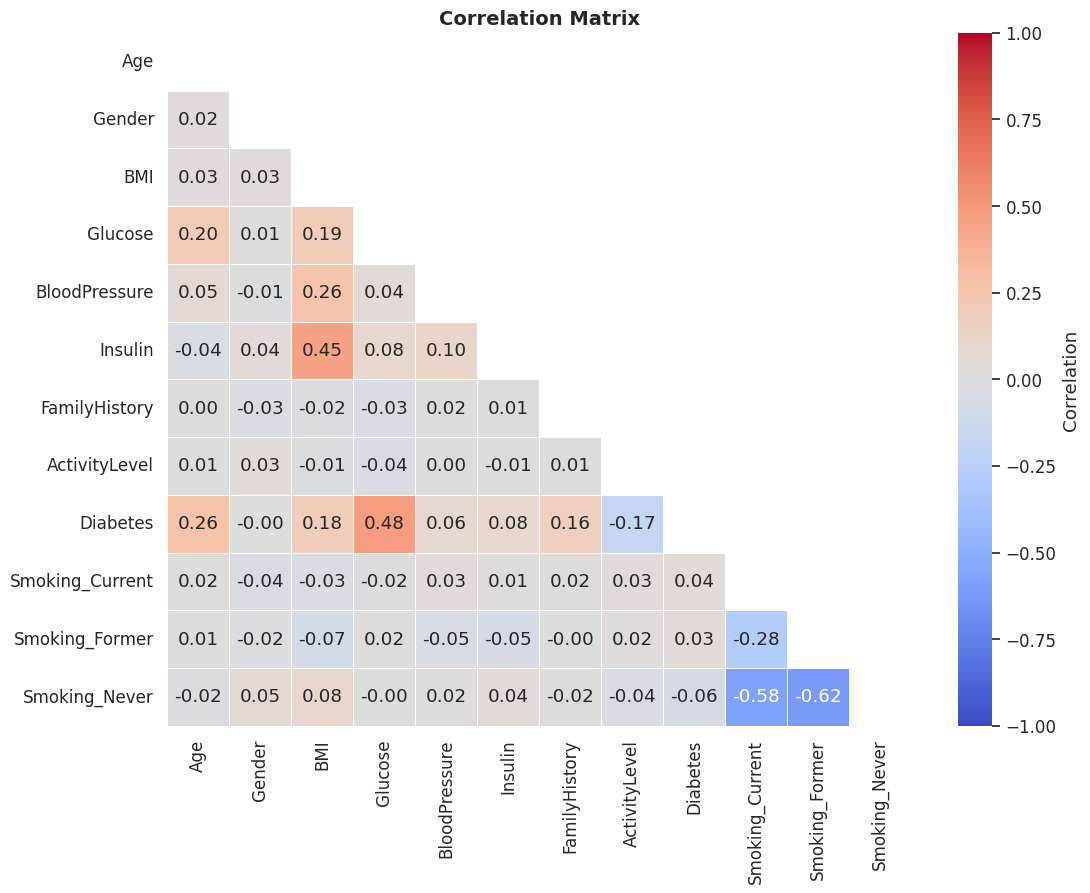

In [21]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.grid(False)
plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.show()

The most useful row is the last one: how much each feature relates to the target. Here it is sorted:

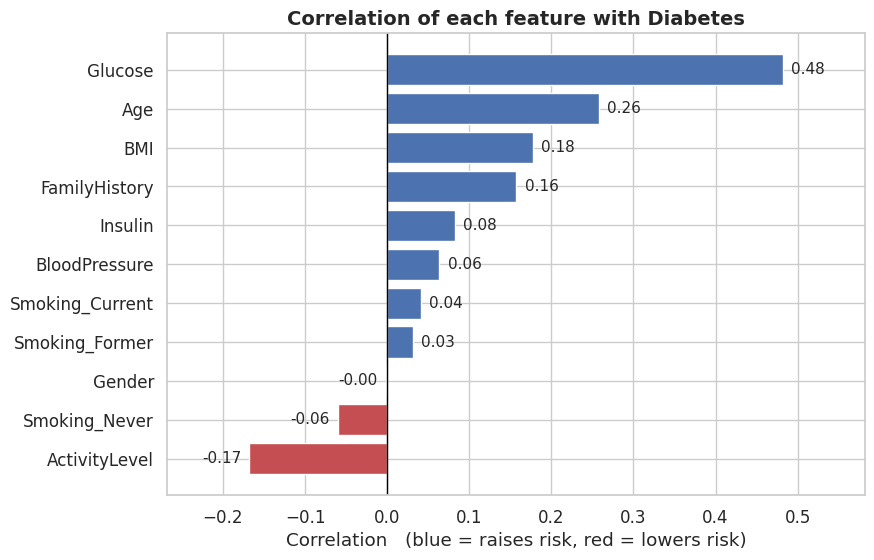

In [22]:
target_corr = corr["Diabetes"].drop("Diabetes").sort_values()
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in target_corr.values]

plt.figure(figsize=(9, 6))
bars = plt.barh(target_corr.index, target_corr.values, color=colors)

for bar, v in zip(bars, target_corr.values):
    offset = 0.01 if v >= 0 else -0.01
    align = "left" if v >= 0 else "right"
    plt.text(v + offset, bar.get_y() + bar.get_height() / 2, f"{v:.2f}",
             va="center", ha=align, fontsize=11)

plt.axvline(0, color="black", linewidth=1)
plt.title("Correlation of each feature with Diabetes", fontsize=14, fontweight="bold")
plt.xlabel("Correlation   (blue = raises risk, red = lowers risk)")
plt.xlim(target_corr.min() - 0.1, target_corr.max() + 0.1)
plt.show()

**How to read it:**
- `Glucose` has the strongest link with diabetes
- `ActivityLevel` is negative: more activity, less diabetes
- Correlation only measures **straight-line** relationships. A weak correlation does not always mean a useless feature

## 7. Train/Test Split and Standardization

### 7.1 Split

```
All data
 ├── Train (80%) : the model learns from it
 └── Test  (20%) : new patients the model has never seen, used once at the end
```
`stratify=y` keeps the same diabetes ratio in both parts.

* **We remove `Diabetes` from `X` because it is the target—the answer we want the model to predict.** Keeping it in `X` would cause **target leakage**, like **giving a student the question and the answer at the same time.**


In [23]:
X = df.drop(columns=["Diabetes"])#Target Leakage.
y = df["Diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("Train:", X_train.shape, "  Diabetes rate:", round(y_train.mean(), 2))
print("Test: ", X_test.shape, "  Diabetes rate:", round(y_test.mean(), 2))

Train: (1200, 11)   Diabetes rate: 0.33
Test:  (300, 11)   Diabetes rate: 0.33


### 7.2 Standardization

Features have very different scales: `Age` is around 50, `Insulin` around 100, `Gender` is 0 or 1.
**StandardScaler** converts each column so that its mean = 0 and its standard deviation = 1:

`z = (value - mean) / std`

**Which columns?** Only the continuous numerical ones. Binary and one-hot columns are already 0/1.

**Rule:** `fit` on Train only (learn the mean and std), then `transform` both Train and Test.

> **Note:** tree models like XGBoost and LightGBM do not need scaling, because a split like "Glucose > 126" works the same on any scale. Scaling matters for models based on distance or weights, such as Logistic Regression, KNN, SVM, and Neural Networks. We apply it here so the pipeline is complete.

In [24]:
scale_cols = ["Age", "BMI", "Glucose", "BloodPressure", "Insulin"]

scaler = StandardScaler()
scaler.fit(X_train[scale_cols])                               # learn from Train only

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[scale_cols] = scaler.transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

comparison = pd.DataFrame({
    "Mean before": X_train[scale_cols].mean(),
    "Std before": X_train[scale_cols].std(),
    "Mean after": X_train_scaled[scale_cols].mean(),
    "Std after": X_train_scaled[scale_cols].std(),
}).round(2)
comparison

,Mean before,Std before,Mean after,Std after
Age,49.61,17.30,-0.0,1.0
BMI,27.99,5.81,-0.0,1.0
Glucose,102.22,21.01,-0.0,1.0
BloodPressure,74.84,9.16,0.0,1.0
Insulin,101.48,37.82,-0.0,1.0


## 8. Models

Both are **Gradient Boosting**: many small trees, each new tree corrects the mistakes of the trees before it.

| | XGBoost | LightGBM |
|---|---|---|
| How the tree grows | **Level-wise**: completes each level | **Leaf-wise**: expands the leaf with the biggest error |
| Speed | Good | Faster on large data |
| Main size control | `max_depth` | `num_leaves` |

### Parameters vs Hyperparameters

| | Hyperparameters | Parameters |
|---|---|---|
| Who sets them? | **We do**, before training | **The model**, during training |
| Examples | number of trees, learning rate, depth | split points like "Glucose > 126", leaf values |

### 8.1 XGBoost

| Hyperparameter | Value | Meaning |
|---|---|---|
| `n_estimators` | 300 | Number of trees |
| `learning_rate` | 0.05 | How much each tree corrects. Smaller = slower but more stable |
| `max_depth` | 4 | Maximum number of questions in one tree path |
| `subsample` | 0.8 | Each tree sees 80% of the patients |
| `colsample_bytree` | 0.8 | Each tree sees 80% of the features |

In [25]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)                  # 0 or 1
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]      # probability of diabetes

### 8.2 LightGBM

| Hyperparameter | Value | Meaning |
|---|---|---|
| `n_estimators` | 300 | Number of trees |
| `learning_rate` | 0.05 | How much each tree corrects |
| `num_leaves` | 15 | Maximum leaves per tree (main control, because growth is leaf-wise) |
| `min_child_samples` | 20 | Minimum patients in a leaf, prevents very specific leaves |
| `subsample` | 0.8 | Each tree sees 80% of the patients |
| `colsample_bytree` | 0.8 | Each tree sees 80% of the features |

In [26]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

lgbm_model.fit(X_train_scaled, y_train)

lgbm_pred = lgbm_model.predict(X_test_scaled)
lgbm_prob = lgbm_model.predict_proba(X_test_scaled)[:, 1]

## 9. Exercise: compute the metrics yourself

Below are **20 patients** from the test set: what really happened (`Actual`) and what XGBoost predicted (`Predicted`).

**Your task, with pen and paper:**
1. Label each row as **TP**, **TN**, **FP**, or **FN**
2. Count each one
3. Compute: **Accuracy**, **Precision**, **Recall**, **F1 Score**

| | Meaning |
|---|---|
| **TP** (True Positive) | Actual = 1, Predicted = 1 |
| **TN** (True Negative) | Actual = 0, Predicted = 0 |
| **FP** (False Positive) | Actual = 0, Predicted = 1 (false alarm) |
| **FN** (False Negative) | Actual = 1, Predicted = 0 (missed patient) |

In [27]:
exercise = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_pred,
}).sample(20, random_state=119).reset_index(drop=True)

exercise.index = exercise.index + 1
exercise.index.name = "Patient"
exercise

,Actual,Predicted
Patient,,
1,1,1
2,1,1
3,1,1
4,0,1
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


**Stop here and solve it before scrolling down.**

<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>

## 10. Answers

### 10.1 The 20 patients, labeled

In [28]:
def outcome(row):
    if row["Actual"] == 1 and row["Predicted"] == 1:
        return "TP"
    if row["Actual"] == 0 and row["Predicted"] == 0:
        return "TN"
    if row["Actual"] == 0 and row["Predicted"] == 1:
        return "FP"
    return "FN"

exercise["Outcome"] = exercise.apply(outcome, axis=1)
exercise

,Actual,Predicted,Outcome
Patient,,,
1,1,1,TP
2,1,1,TP
3,1,1,TP
4,0,1,FP
5,0,0,TN
6,0,0,TN
7,1,1,TP
8,0,0,TN
9,0,0,TN


### 10.2 Confusion Matrix and metrics for the 20 patients

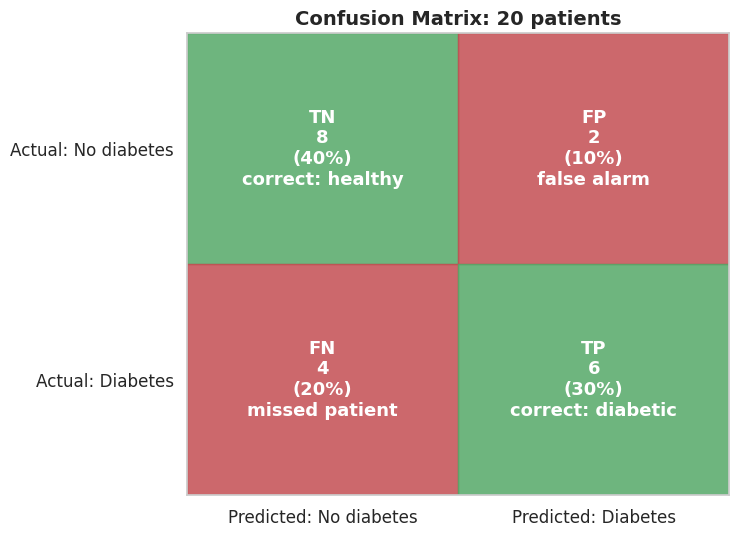

TP = 6   TN = 8   FP = 2   FN = 4   Total = 20

Accuracy  = (TP + TN) / Total        = (6 + 8) / 20       = 0.700
Precision = TP / (TP + FP)           = 6 / (6 + 2)         = 0.750
Recall    = TP / (TP + FN)           = 6 / (6 + 4)         = 0.600
F1 Score  = 2 * P * R / (P + R)      = 2 * 0.750 * 0.600 / (0.750 + 0.600) = 0.667


In [29]:
def plot_confusion_matrix(actual, predicted, title):
    cm = confusion_matrix(actual, predicted)
    names = [["TN", "FP"], ["FN", "TP"]]
    meaning = [["correct: healthy", "false alarm"], ["missed patient", "correct: diabetic"]]
    colors = [["#55A868", "#C44E52"], ["#C44E52", "#55A868"]]
    total = cm.sum()

    fig, ax = plt.subplots(figsize=(7, 6))
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color=colors[i][j], alpha=0.85))
            ax.text(j + 0.5, i + 0.5,
                    f"{names[i][j]}\n{cm[i, j]}\n({cm[i, j] / total:.0%})\n{meaning[i][j]}",
                    ha="center", va="center", fontsize=13, color="white", fontweight="bold")

    ax.set_xlim(0, 2)
    ax.set_ylim(2, 0)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(["Predicted: No diabetes", "Predicted: Diabetes"])
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(["Actual: No diabetes", "Actual: Diabetes"])
    ax.grid(False)
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.show()


def explain_metrics(actual, predicted):
    tn, fp, fn, tp = confusion_matrix(actual, predicted).ravel()
    total = tp + tn + fp + fn

    accuracy = (tp + tn) / total
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall)

    print(f"TP = {tp}   TN = {tn}   FP = {fp}   FN = {fn}   Total = {total}")
    print()
    print(f"Accuracy  = (TP + TN) / Total        = ({tp} + {tn}) / {total}       = {accuracy:.3f}")
    print(f"Precision = TP / (TP + FP)           = {tp} / ({tp} + {fp})         = {precision:.3f}")
    print(f"Recall    = TP / (TP + FN)           = {tp} / ({tp} + {fn})         = {recall:.3f}")
    print(f"F1 Score  = 2 * P * R / (P + R)      = 2 * {precision:.3f} * {recall:.3f} / ({precision:.3f} + {recall:.3f}) = {f1:.3f}")


plot_confusion_matrix(exercise["Actual"], exercise["Predicted"], "Confusion Matrix: 20 patients")
explain_metrics(exercise["Actual"], exercise["Predicted"])

### 10.3 The full test set: XGBoost

Same formulas, now on all test patients.

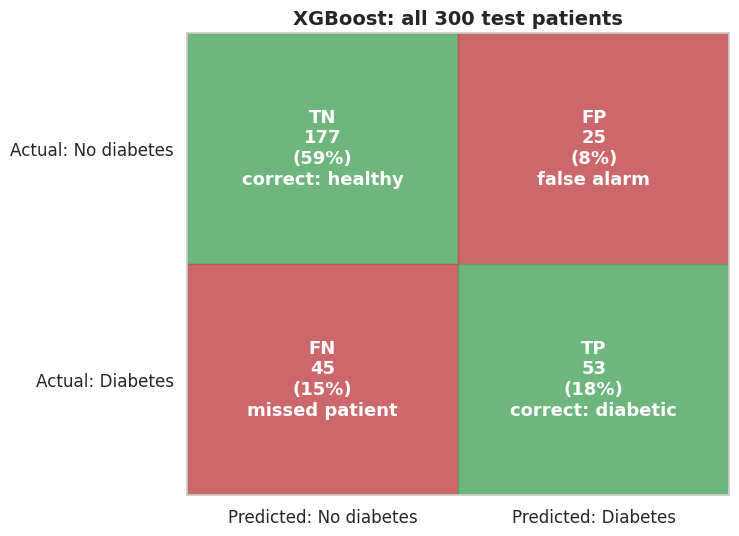

TP = 53   TN = 177   FP = 25   FN = 45   Total = 300

Accuracy  = (TP + TN) / Total        = (53 + 177) / 300       = 0.767
Precision = TP / (TP + FP)           = 53 / (53 + 25)         = 0.679
Recall    = TP / (TP + FN)           = 53 / (53 + 45)         = 0.541
F1 Score  = 2 * P * R / (P + R)      = 2 * 0.679 * 0.541 / (0.679 + 0.541) = 0.602


In [30]:
plot_confusion_matrix(y_test, xgb_pred, f"XGBoost: all {len(y_test)} test patients")
explain_metrics(y_test, xgb_pred)

### 10.4 The full test set: LightGBM

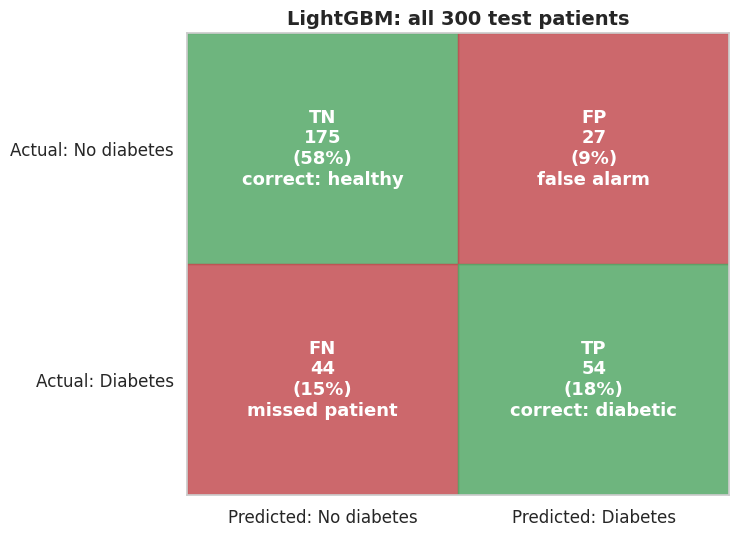

TP = 54   TN = 175   FP = 27   FN = 44   Total = 300

Accuracy  = (TP + TN) / Total        = (54 + 175) / 300       = 0.763
Precision = TP / (TP + FP)           = 54 / (54 + 27)         = 0.667
Recall    = TP / (TP + FN)           = 54 / (54 + 44)         = 0.551
F1 Score  = 2 * P * R / (P + R)      = 2 * 0.667 * 0.551 / (0.667 + 0.551) = 0.603


In [31]:
plot_confusion_matrix(y_test, lgbm_pred, f"LightGBM: all {len(y_test)} test patients")
explain_metrics(y_test, lgbm_pred)

### 10.5 ROC-AUC and PR-AUC

Accuracy, Precision, Recall, and F1 use **one** threshold (0.5). These two curves check **every** threshold.

| Metric | What it measures | How to read it |
|---|---|---|
| **ROC-AUC** | How well the model separates diabetic from non-diabetic patients | 0.5 = random guess, 1.0 = perfect |
| **PR-AUC** | Precision vs Recall, focused on the diabetic class | Baseline = the diabetes rate. More honest when classes are imbalanced |

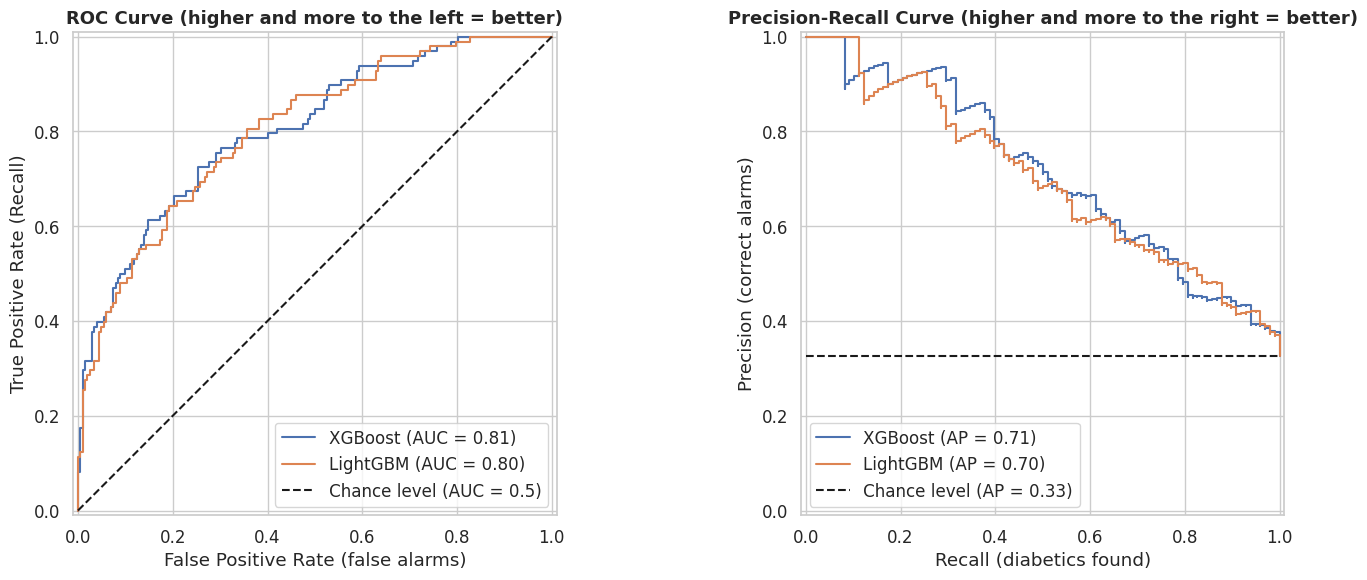

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

RocCurveDisplay.from_predictions(y_test, xgb_prob, name="XGBoost", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, lgbm_prob, name="LightGBM", ax=axes[0], plot_chance_level=True)
axes[0].set_title("ROC Curve (higher and more to the left = better)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate (false alarms)")
axes[0].set_ylabel("True Positive Rate (Recall)")

PrecisionRecallDisplay.from_predictions(y_test, xgb_prob, name="XGBoost", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, lgbm_prob, name="LightGBM", ax=axes[1], plot_chance_level=True)
axes[1].set_title("Precision-Recall Curve (higher and more to the right = better)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recall (diabetics found)")
axes[1].set_ylabel("Precision (correct alarms)")

plt.tight_layout()
plt.show()

### 10.6 All metrics side by side

In [33]:
def all_metrics(actual, predicted, probability):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted),
        "Recall": recall_score(actual, predicted),
        "F1 Score": f1_score(actual, predicted),
        "ROC-AUC": roc_auc_score(actual, probability),
        "PR-AUC": average_precision_score(actual, probability),
    }

results = pd.DataFrame({
    "XGBoost": all_metrics(y_test, xgb_pred, xgb_prob),
    "LightGBM": all_metrics(y_test, lgbm_pred, lgbm_prob),
}).round(3)

results

,XGBoost,LightGBM
Accuracy,0.767,0.763
Precision,0.679,0.667
Recall,0.541,0.551
F1 Score,0.602,0.603
ROC-AUC,0.805,0.803
PR-AUC,0.713,0.700


**Which metric matters most here?** **Recall.** A missed diabetic patient (FN) goes untreated, while a false alarm (FP) only costs one extra blood test.

## 11. SHAP: why did the model decide this?

**Idea:** start from the average patient's risk, then each feature pushes the prediction up or down:
```
Average risk of all patients         30%
+ Glucose is high                   +35%
+ FamilyHistory = Yes               +10%
+ ActivityLevel = High               -8%
= Model prediction for this patient  67%
```
- **Positive SHAP value:** the feature raised the risk
- **Negative SHAP value:** the feature lowered the risk
- **Average + all SHAP values = the model's prediction**

In [34]:
explainer = shap.TreeExplainer(
    xgb_model,
    data=X_train_scaled.sample(200, random_state=0),
    model_output="probability",
)
shap_values = explainer(X_test_scaled)
shap_values.data = X_test.values          # show original values (not scaled) in the plots

print("Average risk (starting point):", round(shap_values.base_values[0], 2))

Average risk (starting point): 0.35


### 11.1 Which features matter most? (Global)

The average size of each feature's push, across all test patients.

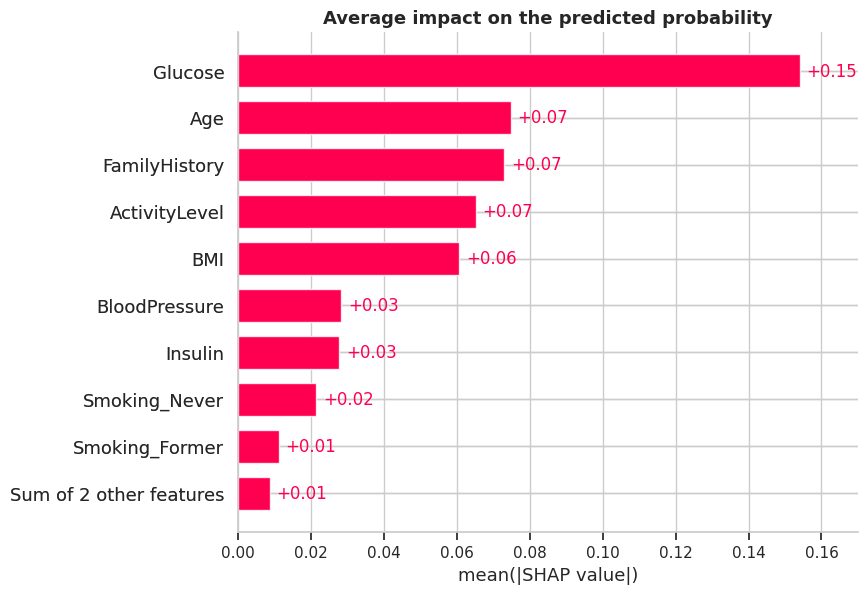

In [35]:
shap.plots.bar(shap_values, show=False)
plt.title("Average impact on the predicted probability", fontsize=13, fontweight="bold")
plt.show()

### 11.2 In which direction? (Beeswarm)

- Each dot = one patient
- **Red** = high value of the feature, **blue** = low value
- **Right** of the center line = raises the risk, **left** = lowers it

Example: `Glucose` red dots are on the right (high sugar raises risk). `ActivityLevel` red dots are on the left (more activity lowers risk).

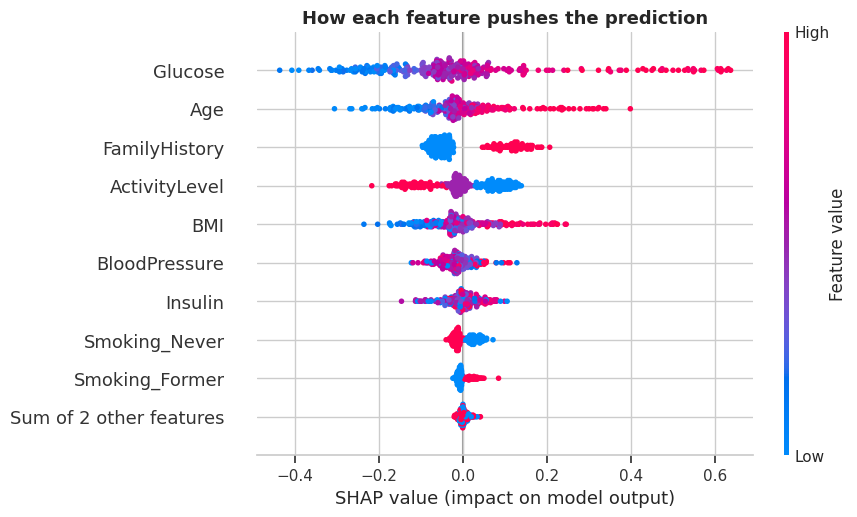

In [36]:
shap.plots.beeswarm(shap_values, show=False)
plt.title("How each feature pushes the prediction", fontsize=13, fontweight="bold")
plt.show()

### 11.3 One patient (Local)

Read from the **bottom** up: start at `E[f(X)]` (average risk), each bar pushes right (red, raises risk) or left (blue, lowers risk), and we end at `f(x)`, this patient's predicted probability.

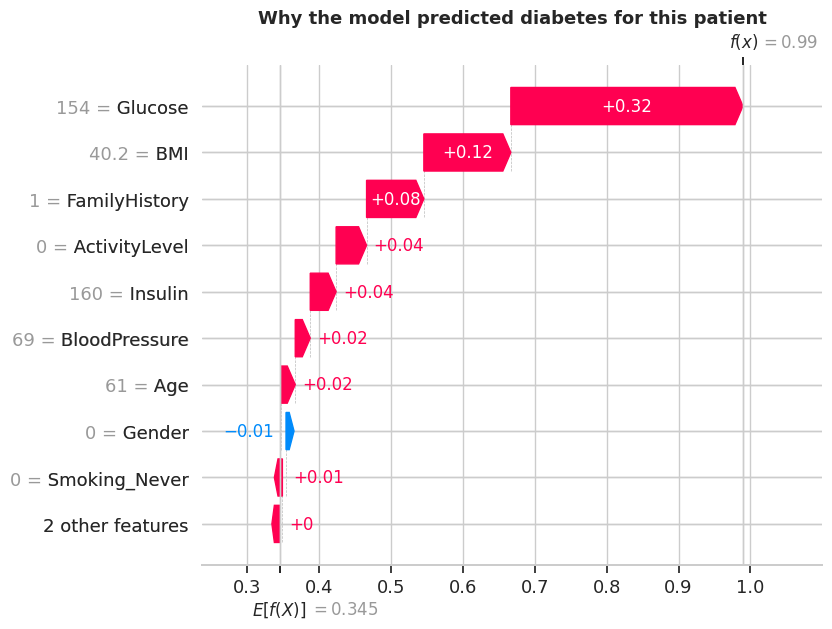

In [37]:
patient = int(np.argmax(xgb_prob))            # the highest-risk patient in the test set

shap.plots.waterfall(shap_values[patient], show=False)
plt.title("Why the model predicted diabetes for this patient", fontsize=13, fontweight="bold")
plt.show()